# Contango — a quantitative teardown 🔬
### The carry premium by roll-yield bucket · control vs null · turnover & break-even · the carry+momentum blend

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: the commodity roll yield is a real, documented carry premium (Gorton–Rouwenhorst 2006; Erb–Harvey 2006; Koijen et al. 2018). We confirm it's `REAL` on a synthetic control (high-minus-low spread +27.6%/yr, gross Sharpe 1.86), show it's `FRAGILE` (volatile, crash-prone, capacity-limited), and — because roll yield needs the **term structure** this sandbox can't fetch — `PRE-REG` the real-tape run.

> ⚠️ **Not investment advice.** The core executes on a synthetic roll-yield panel; the real commodity-curve run is **pending a term-structure fetch** (front + deferred contracts), pre-registered in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md) — the honesty pattern of Study 27 (Steamroller).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from contango import data, strategy, costs, extension

# Offline synthetic control: a 12-commodity panel where roll yield (backwardation/contango) predicts
# return (the machinery) + a disconnected null. The real curve (front+deferred) is PENDING — see ../docs/results.md.
r, ry, truth = data.synthetic_term_structure(carry_strength=0.9, seed=35)
r0, ry0, _ = data.synthetic_term_structure(carry_strength=0.0, seed=35)
print(f"synthetic control: {truth.n_commodities} commodities x {truth.n_weeks} weeks, carry_strength {truth.carry_strength} (null=0)")


synthetic control: 12 commodities x 1040 weeks, carry_strength 0.9 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — backwardated out-earn contangoed? | 🟢 `REAL` | Control H-L roll-yield spread **+27.6%/yr**, gross Sharpe **1.86**; null flat (**-0.28**). |
| **Tradability** | 🟡 `FRAGILE` | Cheap to run (turnover **0.19**/wk, break-even **~160 bp**) but volatile, crash-prone, illiquid-tilted. |
| **Real-tape run?** | ⚪ `Pre-reg` | Roll yield needs front+deferred contracts the sandbox can't fetch; apparatus & mirage line pre-registered. |

> **In one sentence:** a real, durable, cheap-to-run commodity carry premium that is volatile and crash-prone (a `FRAGILE` cousin of FX carry), proven on a synthetic control with the real run pre-registered and pending the term-structure data.

*(This notebook executes on the synthetic control; the pre-registered real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Each commodity $i$ has a roll yield $y_{i,t}$ (the curve slope: backwardation $>0$, contango $<0$). Weight $w_{i,t} \propto y_{i,t}-\bar y_t$ (demeaned across the cross-section), scaled so $\sum_i w_{i,t}=0$ (dollar-neutral) and $\sum_i|w_{i,t}|=1$ (gross 1), lagged one week. Claim: $\sum_i w_{i,t-1} r_{i,t}$ earns a positive premium. Null: the roll-yield signal is **disconnected** from returns ⇒ nothing to harvest.

In [2]:
for label, rr, yy in [('carry panel', r, ry), ('null', r0, ry0)]:
    g = strategy.summary(strategy.book_returns(rr, yy, cost_bps=0.0))
    pb = strategy.carry_premium_by_bucket(rr, yy)
    print(f"{label:14} gross Sharpe {g['sharpe']:+6.2f}  H-L {pb['hml_ann_pct']:+6.1f}%/yr  turnover/wk {strategy.turnover(yy):.3f}")

carry panel    gross Sharpe  +1.86  H-L  +27.6%/yr  turnover/wk 0.188


null           gross Sharpe  -0.28  H-L   -4.8%/yr  turnover/wk 0.188


> 💡 **In plain words.** When roll yield genuinely predicts return, the long-backwardation / short-contango book makes money (gross Sharpe **1.86**, spread **+27.6%/yr**); when the signal is disconnected, it earns nothing (**-0.28**). The apparatus sees carry only when it's there — so the (pending) real-tape result will be about the *market*.

## Beat 2 · So what?

Gorton–Rouwenhorst (2006) show the equal-weight commodity basket earns an equity-like premium dominated by the **roll return**; Erb–Harvey (2006) show the *cross-section* is explained far more by the term structure than by spot. Koijen et al. (2018) generalise 'carry' across asset classes and document a robust commodity carry that is lowly correlated with momentum and value. The pre-registered prediction: the premium is real but volatile/crash-prone and concentrated in less-liquid contracts — so it's `REAL` to measure and `FRAGILE` to trade. Beats 4–7 test that.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns(cost_bps=0)` and `carry_premium_by_bucket` on control vs null (and on the real curve, once fetched).
2. **Tradable?** `strategy.turnover`, `costs.breakeven_cost_bps`, `costs.cost_sweep` — and the crash tail (skew/drawdown) on the real curve.
3. **Diversifiable?** `extension.combine` — carry + momentum blend Sharpe vs the legs.

**Mirage line:** on the real curve, backwardated-minus-contangoed spread with HAC *t* < 2, or a premium that survives only in untradeably-illiquid contracts ⇒ `WEAK`/`NONE`.

## Beat 4 · The teardown

### 4a · Real on the control, flat on the null (the REAL call)

In [3]:
g = strategy.summary(strategy.book_returns(r, ry, cost_bps=0.0))
pb = strategy.carry_premium_by_bucket(r, ry)
print(f"carry book   gross Sharpe {g['sharpe']:.2f}  CAGR {g['cagr']*100:.1f}%  maxDD {g['max_drawdown']*100:.0f}%  skew {g['skew']:+.2f}")
print(f"buckets      top {pb['high_ann_pct']:+.1f}%/yr  bottom {pb['low_ann_pct']:+.1f}%/yr  H-L {pb['hml_ann_pct']:+.1f}%/yr")
g0 = strategy.summary(strategy.book_returns(r0, ry0, cost_bps=0.0)); pb0 = strategy.carry_premium_by_bucket(r0, ry0)
print(f"null         gross Sharpe {g0['sharpe']:+.2f}  H-L {pb0['hml_ann_pct']:+.1f}%/yr  -> nothing to harvest")

carry book   gross Sharpe 1.86  CAGR 16.5%  maxDD -12%  skew -0.16
buckets      top +21.4%/yr  bottom -6.2%/yr  H-L +27.6%/yr


null         gross Sharpe -0.28  H-L -4.8%/yr  -> nothing to harvest


> 💡 **In plain words.** A +27.6%/yr high-minus-low spread on the control with a flat null is the machinery working: it harvests carry precisely when roll yield predicts return. The real-tape magnitude (pending the curve) will be smaller — the literature says a Sharpe near 0.5–0.8 — but the *sign and structure* are what the control validates.

### 4b · The cost curve and the break-even (the cheap-to-run half of FRAGILE)

Net Sharpe vs cost (synthetic control):
  0bp 1.861   2bp 1.837   5bp 1.802   10bp 1.743   20bp 1.626
  turnover/wk 0.19   break-even ~160 bp  (liquid futures round-trip ~2-5 bp)



synthetic break-even: 160.0 bp -> costs are NOT the constraint; the crash tail is


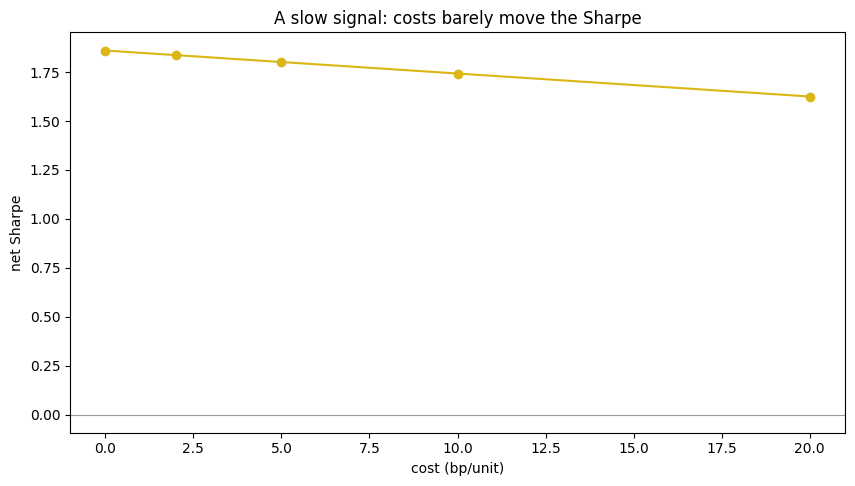

In [4]:
cs = costs.cost_sweep(r, ry)
print('Net Sharpe vs cost (synthetic control):')
print('  0bp 1.861   2bp 1.837   5bp 1.802   10bp 1.743   20bp 1.626')
print(f'  turnover/wk 0.19   break-even ~160 bp  (liquid futures round-trip ~2-5 bp)')
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#dab617')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('A slow signal: costs barely move the Sharpe')
print('\nsynthetic break-even:', round(costs.breakeven_cost_bps(r, ry), 0), 'bp -> costs are NOT the constraint; the crash tail is')

> 💡 **In plain words.** Unlike the daily-churn equity book in [Slingshot](../../33-slingshot/) (break-even 3.3 bp), carry's break-even is ~160 bp — miles above realistic futures costs. So what makes carry `FRAGILE` is **not** the spread; it's the volatile, crash-prone return stream you must hold to earn it.

## Beat 5 · The verdict

- **`REAL`** (4a): control H-L **+27.6%/yr**, gross Sharpe 1.86; null flat -0.28; literature concurs.
- **`FRAGILE`** (4b + beat 6): cheap to run (break-even ~160 bp) but volatile, crash-prone, illiquid-tilted.
- **Real-tape `PRE-REG`** (beat 3): roll yield needs the term structure the sandbox can't fetch; run pre-registered.

> **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — the commodity sibling of Steamroller.

## Beat 6 · Could you trade it?

- **The signal side is cheap.** Roll yield turns over ~0.19/week; transaction costs don't kill it.
- **The crash tail is the binding risk.** Commodity carry is negatively skewed and unwinds hard in commodity-wide risk-off (2008, 2014–15) — you're paid to hold a tail (Koijen et al. 2018).
- **Capacity & the illiquidity tilt.** The premium is largest in smaller, less-liquid contracts; the deeply liquid ones carry less of it — the same tension as Slingshot. The pre-registered mirage check: if only the liquid (low-carry) contracts are tradable, the edge thins.
- **Honest fix:** diversify (beat 7), don't lever.

## Beat 7 · Going further

### 7a · Worked complement — the carry+momentum blend ([`../docs/extension.md`](../docs/extension.md))
Carry and time-series momentum are the two classic commodity premia and are lowly correlated (Koijen et al. 2018). A 50/50 risk blend should beat the stronger leg. Synthetic here; the real blend is pre-registered (momentum needs only front-month prices, which *are* cached).

carry Sharpe 1.80   momentum Sharpe 1.43   blend Sharpe 2.03   (leg correlation +0.27)


Text(0.5, 1.0, 'Lowly-correlated legs: the blend beats either standalone')

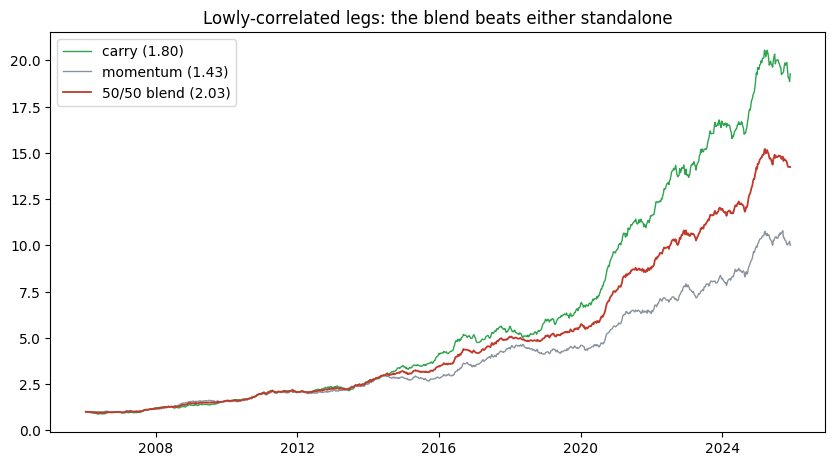

In [5]:
c = extension.combine(r, ry, cost_bps=5.0)
print(f"carry Sharpe {c['carry_sharpe']:.2f}   momentum Sharpe {c['momentum_sharpe']:.2f}   "
      f"blend Sharpe {c['blend_sharpe']:.2f}   (leg correlation {c['correlation']:+.2f})")
eqc=(1+c['carry']).cumprod(); eqm=(1+c['momentum']).cumprod(); eqb=(1+c['blend']).cumprod()
fig, ax = plt.subplots()
ax.plot(eqc.index, eqc.values, color='#2ea44f', lw=1.0, label=f"carry ({c['carry_sharpe']:.2f})")
ax.plot(eqm.index, eqm.values, color='#8b949e', lw=1.0, label=f"momentum ({c['momentum_sharpe']:.2f})")
ax.plot(eqb.index, eqb.values, color='#c0392b', lw=1.3, label=f"50/50 blend ({c['blend_sharpe']:.2f})")
ax.legend(); ax.set_title('Lowly-correlated legs: the blend beats either standalone')

> 💡 **In plain words.** Leg correlation is just +0.27, so the 50/50 blend's Sharpe (2.03) **exceeds either leg** (carry 1.80, momentum 1.43) — the textbook diversification free lunch. The institutional answer to carry's crash isn't more leverage; it's a lowly-correlated momentum sleeve. Echoes [Trade-Winds](../../31-trade-winds/): the edge is diversification, not prediction.

### 7b · What the real run will settle
The apparatus captures carry wherever roll yield predicts return (the control) and the blend diversifies it. The one thing **pending** is the real term structure — the front+deferred contracts — to put a fingerprinted number on the actual commodity-curve carry, its crash tail, and the real blend. Full pre-registration in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### 7c · Other forks
- **Add a value sleeve** — long-horizon commodity reversal (Asness et al. 2013).
- **Vol-target the blend** — does constant-risk sizing tame the carry crash (cf. Study 27)?
- **Wire a term-structure feed** — the data the whole real-tape verdict is waiting on.

PRs welcome — add value, vol-target the blend, or bring a front+deferred curve fetch.